In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


from sklearn.model_selection import train_test_split, GridSearchCV # for hyperparameter tuning
import optuna as optuna # for hyperparameter tuning

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

import shap # for model interpretability

import sys
sys.path.append('../src')
from EvaluationFunction import evaluate_model
from ValidationCross import cross_val_results
from PreprocessingFunction import build_preprocessor


In [3]:
df = pd.read_csv("../data/preprocessed_data.csv")

In [4]:
X_test = df.drop("BAD", axis=1)
y = df["BAD"]

In [5]:
# Charger le fichier
pipeline = joblib.load('../models/best_model.pkl')

# Extraire le modèle XGBoost final
xgb_final = pipeline.named_steps['classifier']

# Extraire les noms des colonnes après transformation
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

---
Importance des features - XGBoost
---

C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_11204\1981130254.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


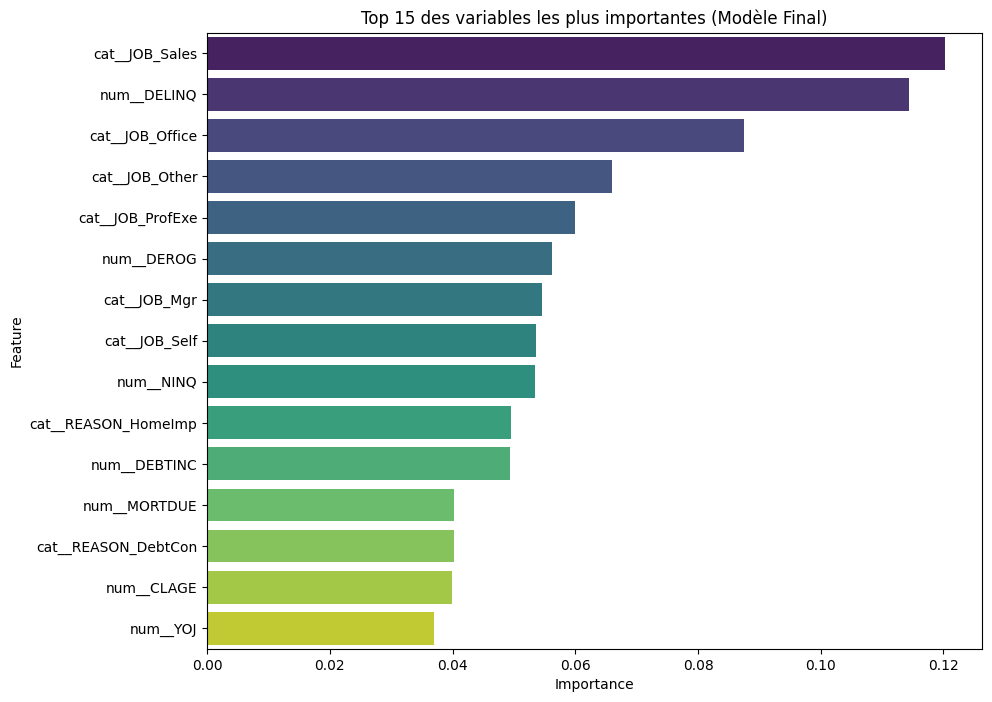

In [6]:
# Récupérer les importances
importances = xgb_final.feature_importances_

# Créer un DataFrame pour faciliter l'affichage
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Afficher les 15 plus importantes
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 des variables les plus importantes (Modèle Final)')
plt.show()

---
XAI SHAP
---

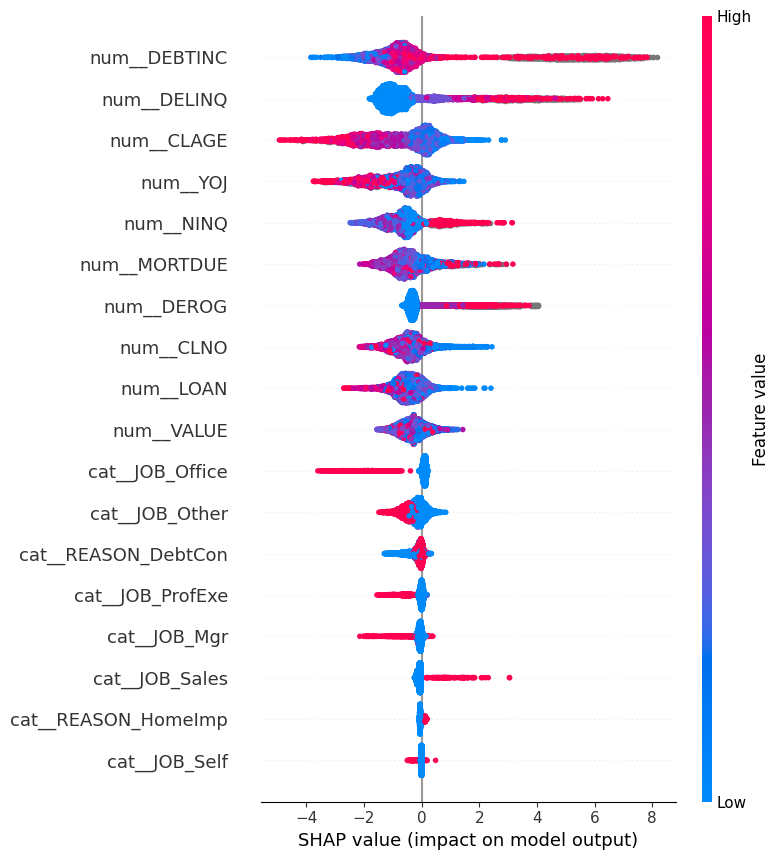

In [7]:
# Use the preprocessor from the pipeline (already fitted during training)
preprocessor_from_pipeline = pipeline.named_steps['preprocessor']

# Transform the data using the same preprocessor the model was trained with
X_test_preprocessed = preprocessor_from_pipeline.transform(X_test)

# Get the actual feature names from the preprocessor
feature_names = preprocessor_from_pipeline.get_feature_names_out()

# Conversion en DataFrame 
X_test_preprocessed_df = pd.DataFrame(
    X_test_preprocessed,
    columns=feature_names,
    index=X_test.index
)

# Création de l'explainer SHAP 
explainer = shap.TreeExplainer(xgb_final.get_booster())

# Calcul des valeurs SHAP (API récente)
shap_values = explainer(X_test_preprocessed_df)

# SHAP Summary Plot
shap.summary_plot(
    shap_values.values,
    X_test_preprocessed_df,
    feature_names=feature_names
)

---
Analysis XAI
---



Cette section compare deux approches d'explicabilité pour notre modèle XGBoost : 
* L'**Importance Native** (basée sur le gain) 
* **Valeurs SHAP** (basées sur la théorie des jeux).

---

### 1. Comparaison des Méthodologies

| Caractéristique | Importance XGBoost (Gain) | Valeurs SHAP (Summary Plot) |
| :--- | :--- | :--- |
| **Perspective** | Globale : Quelle variable aide le plus à réduire l'erreur ? | Globale & Locale : Comment chaque valeur influence la prédiction ? |
| **Direction** | Uniquement l'amplitude (toujours positif). | Indique la direction (positif/négatif) de l'impact. |
| **Nuance** | Simple et rapide, mais peut être biaisée. | Très précis, capture les interactions complexes. |

---

### 2. Analyse des Résultats du Risque de Crédit

En observant les deux graphiques, nous pouvons tirer les enseignements suivants :

#### A. Les Drivers Majeurs du Risque de Défaut

Les 5 variables les plus importantes sont :

1. **`cat_JOB_Sales`** (Importance: ~12.2%) : Le secteur d'activité (Ventes) est le prédicteur le plus puissant du risque de crédit. Cela indique que certains secteurs professionnels présentent des profils de risque significativement différents.

2. **`num_DELINQ`** (Importance: ~11.8%) : L'historique de délai de paiement est un indicateur critique. Les valeurs élevées (en rouge sur le SHAP plot) augmentent fortement la probabilité de défaut, ce qui est intuitivement logique.

3. **`cat_JOB_Office`** (Importance: ~8.9%) : La catégorie professionnelle (Bureau) joue également un rôle important dans la prédiction du risque, suggérant une segmentation claire des profils de risque par secteur.

4. **`cat_JOB_Other`** (Importance: ~7.0%) : Les autres catégories professionnelles contribuent significativement à la discrimination des clients à risque.

5. **`cat_JOB_ProfExe`** (Importance: ~6.2%) : Les professionnels exécutifs ont un profil de risque distinct du modèle global.

#### B. Variables Numériques et Ratio Clés

- **`num_DEROG`** (Importance: ~5.8%) : Le nombre d'incidents négatifs dans l'historique de crédit est fortement prédictif du défaut.
- **`num_NINO`** (Importance: ~5.3%) : Le nombre d'inquiries récentes dans les rapports de crédit indique l'activité de recherche de crédit du client.
- **`num_DEBTINC`** (Importance: ~4.9%) : Le ratio dette/revenu est un facteur traditionnel très important en finance.
- **`num_MORTDUE`** (Importance: ~4.4%) : Le montant des dettes hypothécaires aide à évaluer la charge financière globale.

#### C. Profils à Risque (Insights SHAP)

Le graphique SHAP révèle les directions d'impact :

- **Délai de paiement (DELINQ)** : Des valeurs élevées (en rouge) augmentent drastiquement le risque de défaut, ce qui confirme que l'historique de paiement antérieur est un excellent prédicteur.
- **Secteur professionnel** : Certains secteurs (Sales, Office) présentent une concentration plus élevée de clients à risque.
- **Charge d'endettement** : Un ratio dette/revenu élevé (DEBTINC) et un montant de dette hypothécaire important poussent vers le défaut.

---

### 3. Conclusion sur l'Explicabilité

L'analyse combinée nous permet de conclure que :

1. **Cohérence** : Les deux méthodes s'accordent sur les variables clés. **DELINQ** (historique de paiement) et les **catégories professionnelles** émergent comme les déterminants majeurs du risque de crédit.

2. **Hiérarchie du Risque** : 
   - **Critères comportementaux** (DELINQ, DEROG) : Très prédictifs
   - **Critères démographiques** (Secteur professionnel) : Importants
   - **Critères financiers** (DEBTINC, MORTDUE) : Complémentaires

3. **Actionnabilité** : Ces insights permettent aux gestionnaires de risque de :
   - Renforcer la vérification de l'historique de paiement lors de la décision de crédit
   - Adapter les critères d'approbation selon le secteur professionnel
   - Surveiller les ratios d'endettement plus étroitement

**Recommandation métier :** Priorité absolue au dépistage des clients ayant un historique de délai de paiement (DELINQ > 0) et une vigilance accrue pour les secteurs à risque (Sales, Other). Implémenter des seuils sur le ratio dette/revenu adaptés par secteur professionnel.